# 🎬🌳 Notebook: Árbol de Clasificación Binaria (1-0)

In [1]:
# Celda 0 — Conexión a etl-proyecto
import sys
import os

# Detectar raíz del proyecto
if "notebooks" in os.getcwd():
    ROOT_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    ROOT_DIR = os.getcwd()

ETL_DIR = os.path.join(ROOT_DIR, "Etl-Proyecto")

if ETL_DIR not in sys.path:
    sys.path.append(ETL_DIR)

print("📁 ROOT_DIR:", ROOT_DIR)
print("📁 ETL_DIR:", ETL_DIR)

# Celda X — Configuración de directorio para gráficas

# Ruta base del proyecto ETL
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))

# Carpeta donde se guardarán las gráficas
GRAFICAS_DIR = os.path.join(BASE_DIR, "data",  'graficas', 'arbol_de_decisión_para_clasificación')

# Crear carpeta si no existe
os.makedirs(GRAFICAS_DIR, exist_ok=True)

print(f"📁 Gráficas se guardarán en: {GRAFICAS_DIR}")

📁 ROOT_DIR: /home/desarrollo/Grupo6_Obregon_Heredia_MD1
📁 ETL_DIR: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/Etl-Proyecto
📁 Gráficas se guardarán en: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decisión_para_clasificación


## I. CONFIGURACIÓN INICIAL (1–6)

In [2]:
# Celda 1 — Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

from scripts.database import engine

sns.set_theme(style="whitegrid")

In [3]:
# Celda 2 — Query PostgreSQL (OMDb)

QUERY = """
SELECT 
    imdb_rating,
    anio,
    genero,
    director,
    actores
FROM registro_peliculas
WHERE imdb_rating IS NOT NULL
"""

df = pd.read_sql(QUERY, engine)

print(f"✅ Registros cargados: {len(df)}")
df.head()

✅ Registros cargados: 528


,imdb_rating,anio,genero,director,actores
0,8.8,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio..."
1,8.7,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch..."
2,9.1,2008,"Action, Crime, Drama",Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart"
3,8.5,2019,"Drama, Thriller",Bong Joon Ho,"Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong"
4,7.9,2009,"Action, Adventure, Fantasy",James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver"


In [4]:
# Celda 3 — Limpieza de datos

# Convertir año a numérico
df["anio"] = pd.to_numeric(df["anio"], errors="coerce")

# Convertir rating a numérico
df["imdb_rating"] = pd.to_numeric(df["imdb_rating"], errors="coerce")

# Eliminar nulos
df.dropna(inplace=True)

print("✅ Datos limpios")
print(df.info())

df.head()

✅ Datos limpios
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 528 entries, 0 to 527
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   imdb_rating  528 non-null    float64
 1   anio         528 non-null    int64  
 2   genero       528 non-null    object 
 3   director     528 non-null    object 
 4   actores      528 non-null    object 
dtypes: float64(1), int64(1), object(3)
memory usage: 20.8+ KB
None


,imdb_rating,anio,genero,director,actores
0,8.8,2010,"Action, Adventure, Sci-Fi",Christopher Nolan,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ellio..."
1,8.7,2014,"Adventure, Drama, Sci-Fi",Christopher Nolan,"Matthew McConaughey, Anne Hathaway, Jessica Ch..."
2,9.1,2008,"Action, Crime, Drama",Christopher Nolan,"Christian Bale, Heath Ledger, Aaron Eckhart"
3,8.5,2019,"Drama, Thriller",Bong Joon Ho,"Song Kang-ho, Lee Sun-kyun, Cho Yeo-jeong"
4,7.9,2009,"Action, Adventure, Fantasy",James Cameron,"Sam Worthington, Zoe Saldaña, Sigourney Weaver"


In [5]:


# Celda 4 — Variable objetivo binaria

def clasificar_pelicula(rating):
    if rating >= 7:
        return 1
    else:
        return 0

df["Categoria"] = df["imdb_rating"].astype(float).apply(clasificar_pelicula)

print("✅ Clasificación binaria creada")
print(df["Categoria"].value_counts())

✅ Clasificación binaria creada
Categoria
1    367
0    161
Name: count, dtype: int64


In [6]:
# Celda 5 — Distribución de clases
df["Categoria"].value_counts()

Categoria
1    367
0    161
Name: count, dtype: int64

✅ Gráfica guardada en:
/home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decisión_para_clasificación/distribucion_categorias.png


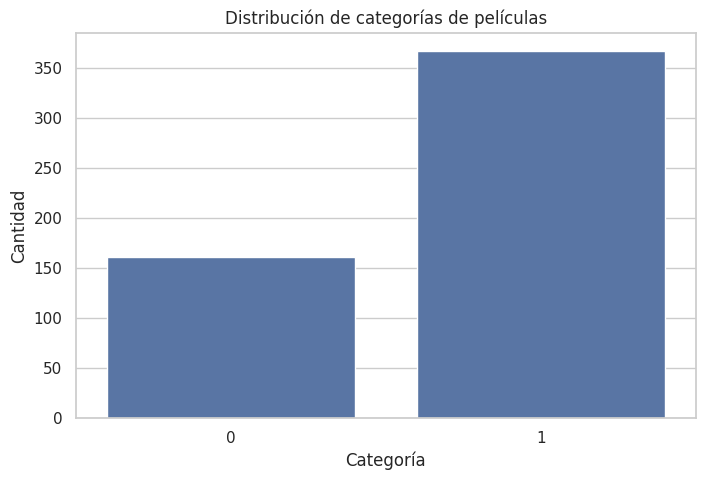

In [7]:
# Celda 6 — Visualización

plt.figure(figsize=(8,5))

sns.countplot(data=df, x="Categoria")

plt.title("Distribución de categorías de películas")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

ruta = os.path.join(
    GRAFICAS_DIR,
    "distribucion_categorias.png"
)

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Gráfica guardada en:\n{ruta}")

plt.show()

## II. VARIABLES (7)

In [8]:
# Celda 7 — Features y target


X = df[["anio", "imdb_rating"]].values

y = df["Categoria"].values

print("✅ Features creadas correctamente")
print("Shape X:", X.shape)
print("Shape y:", y.shape)

✅ Features creadas correctamente
Shape X: (528, 2)
Shape y: (528,)


## III. FUNCIÓN CENTRAL (8–11)

In [12]:
# Celda 8 — Función evaluación
def evaluar_clasificacion(X, y, test_size, label):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    modelo = DecisionTreeClassifier(random_state=42)
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n📊 {label}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")

    return modelo, X_test, y_test, y_pred


print("✅ Función evaluar_clasificacion creada")

✅ Función evaluar_clasificacion creada


In [30]:
# Celda 9 — Split 80/20
modelo_s1, X_test_s1, y_test_s1, y_pred_s1 = evaluar_clasificacion(X, y, 0.2, "Split 80/20")


📊 Split 80/20
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [31]:
# Celda 10 — Split 70/30
modelo_s2, X_test_s2, y_test_s2, y_pred_s2 = evaluar_clasificacion(X, y, 0.3, "Split 70/30")


📊 Split 70/30
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


In [32]:
# Celda 11 — Split 60/40
modelo_s3, X_test_s3, y_test_s3, y_pred_s3 = evaluar_clasificacion(X, y, 0.4, "Split 60/40")


📊 Split 60/40
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.0000


## IV. EVALUACIÓN (12–18)

In [28]:
# Celda 12
def plot_confusion(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

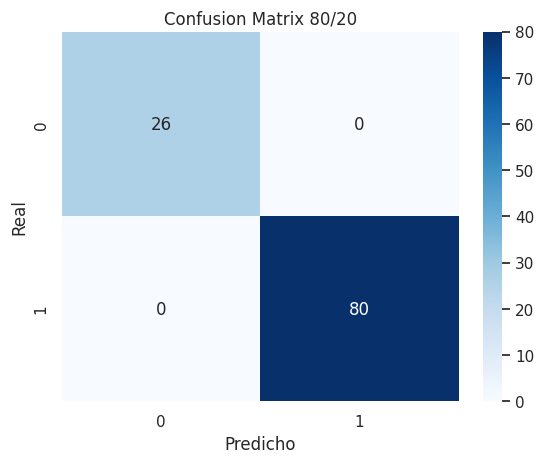

In [27]:
# Celda 13
plot_confusion(y_test_s1, y_pred_s1, "Confusion Matrix 80/20")

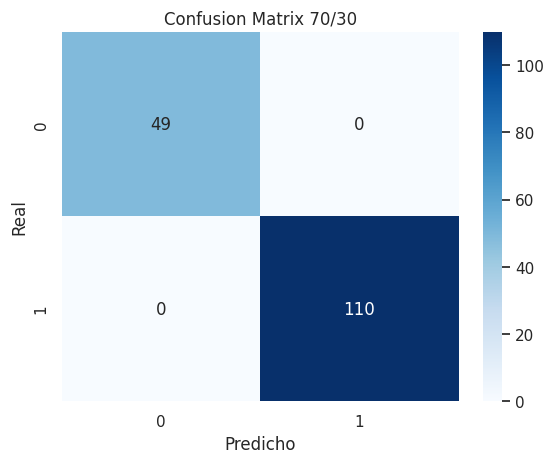

In [26]:
# Celda 14
plot_confusion(y_test_s2, y_pred_s2, "Confusion Matrix 70/30")

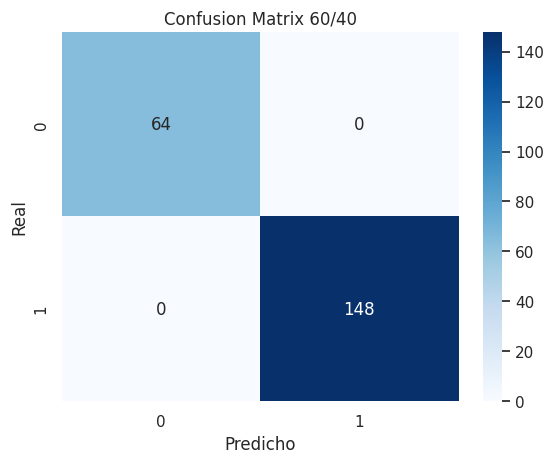

In [25]:
# Celda 15
plot_confusion(y_test_s3, y_pred_s3, "Confusion Matrix 60/40")

In [24]:
# Celda 16
print(classification_report(y_test_s1, y_pred_s1))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        80

    accuracy                           1.00       106
   macro avg       1.00      1.00      1.00       106
weighted avg       1.00      1.00      1.00       106



In [33]:
# Celda 17
resultados = pd.DataFrame({
    "Split": ["80/20", "70/30", "60/40"],
    "Accuracy": [
        accuracy_score(y_test_s1, y_pred_s1),
        accuracy_score(y_test_s2, y_pred_s2),
        accuracy_score(y_test_s3, y_pred_s3),
    ]
})
resultados

,Split,Accuracy
0,80/20,1.0
1,70/30,1.0
2,60/40,1.0


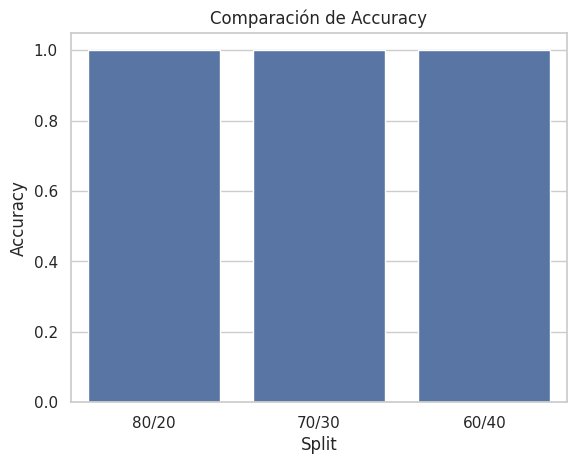

In [34]:
# Celda 18
sns.barplot(data=resultados, x="Split", y="Accuracy")
plt.title("Comparación de Accuracy")
plt.savefig(ruta, bbox_inches="tight")
plt.show()


## V. VISUALIZACIÓN DEL ÁRBOL (19–23)

✅ Árbol guardado en: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decisión_para_clasificación/arbol_clasificacion_binaria.png


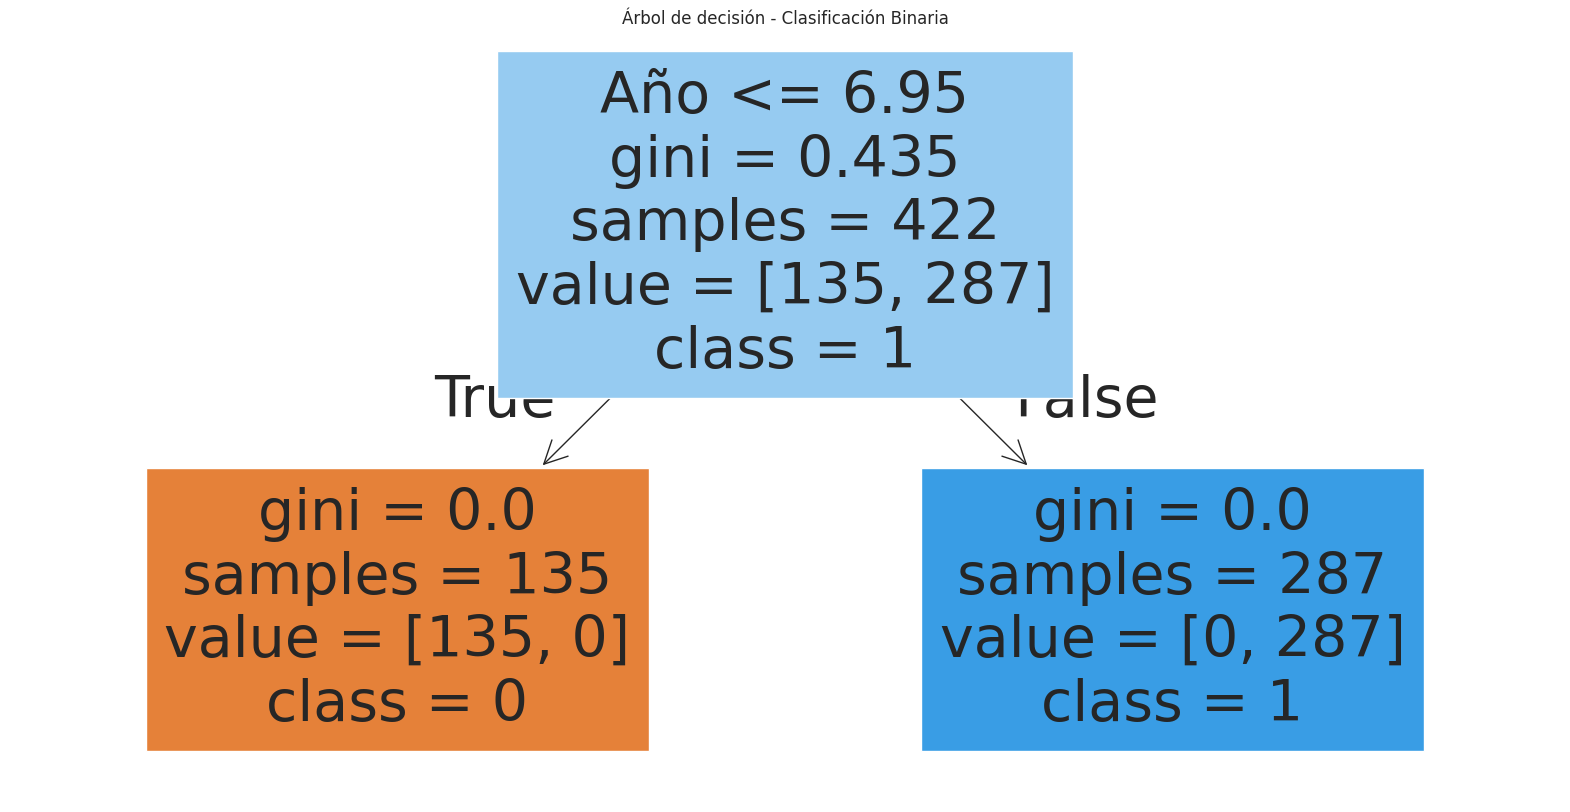

In [36]:
# Celda 19


plt.figure(figsize=(20,10))

plot_tree(
    modelo_s1,
    feature_names=["IMDb_Rating", "Año"],
    class_names=["0", "1"],   # <- convertir a texto
    filled=True
)

ruta = os.path.join(
    GRAFICAS_DIR,
    "arbol_clasificacion_binaria.png"
)

plt.title("Árbol de decisión - Clasificación Binaria")

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Árbol guardado en: {ruta}")

plt.show()

In [37]:
# Celda 20
modelo_simple = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_simple.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

✅ Gráfica guardada en: /home/desarrollo/Grupo6_Obregon_Heredia_MD1/data/graficas/arbol_de_decisión_para_clasificación/arbol_simple.png


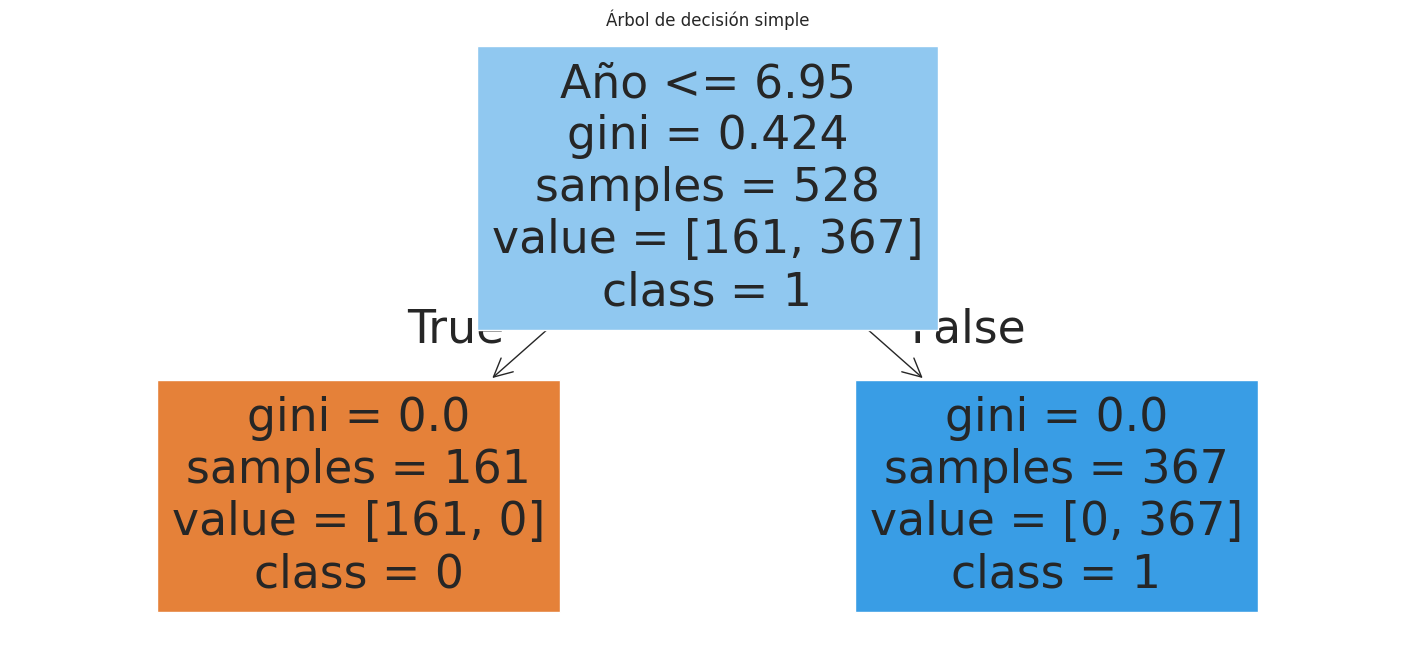

In [39]:
# Celda 21

plt.figure(figsize=(18,8))

plot_tree(
    modelo_simple,
    feature_names=["IMDb_Rating", "Año"],
    class_names=["0", "1"],
    filled=True
)

ruta = os.path.join(
    GRAFICAS_DIR,
    "arbol_simple.png"
)

plt.title("Árbol de decisión simple")

plt.savefig(ruta, bbox_inches="tight")

print(f"✅ Gráfica guardada en: {ruta}")

plt.show()

In [40]:
# Celda 22

from sklearn.tree import export_text

print(
    export_text(
        modelo_simple,
        feature_names=["Anio", "IMDB_Rating"]
    )
)

|--- IMDB_Rating <= 6.95
|   |--- class: 0
|--- IMDB_Rating >  6.95
|   |--- class: 1



In [41]:
# Celda 23 — Ejemplo

prediccion = modelo_simple.predict([[2020, 8.2]])

if prediccion[0] == 1:
    print("🎬 Predicción: Película Exitosa")
else:
    print("🎬 Predicción: Película No Exitosa")

🎬 Predicción: Película Exitosa


## VI. OPTIMIZACIÓN (24–26)

In [42]:
# Celda 24
modelo_reg = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)
modelo_reg.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [43]:
# Celda 25
y_pred_reg = modelo_reg.predict(X_test_s1)
print("Accuracy regularizado:", accuracy_score(y_test_s1, y_pred_reg))

Accuracy regularizado: 1.0


In [44]:
# Celda 26
print("El modelo regularizado reduce overfitting.\n")
print("Árbol de clasificación aplicado correctamente a datos de OMDb.")

El modelo regularizado reduce overfitting.

Árbol de clasificación aplicado correctamente a datos de OMDb.
